## Step 2.1 — Reproducibility Setup

To ensure reproducibility of the experimental results, all sources of randomness are explicitly fixed.
This includes Python internal hashing, NumPy random generation, and TensorFlow stochastic operations.

Fixing the random seeds guarantees that model initialization, data shuffling, and training behavior
remain consistent across multiple runs, as required by the project guidelines.


In [1]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Random seeds fixed to {seed}")

set_seeds(42)


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Random seeds fixed to 42


## Step 2 — Dataset construction (Latent coordinates + PCA on forces and velocity)

This step builds the final learning dataset starting from the standardized inputs produced in Step 1.

1. Coordinates are compressed through an autoencoder, producing a 32-dimensional latent representation.
   The decoder uses a linear output layer to avoid value clipping and ensure consistent reconstruction
   under standardization.

2. Forces and velocities are reduced through PCA to 32 components each, preserving the main variance
   directions while controlling dimensionality.

3. The three representations (latent coordinates, force PCA, velocity PCA) are concatenated into a single
   feature vector per timestep and split into train/validation/test using a chronological split
   (70% / 20% / 10%), avoiding leakage across time.


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.decomposition import PCA
import os
import joblib

BASE_PATH = ""
OUT_PATH = "data_ready"
os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

FILE_COORDS = os.path.join(BASE_PATH, "coordinates_scaled.csv")
FILE_FORCES = os.path.join(BASE_PATH, "forces_scaled.csv")
FILE_VELS = os.path.join(BASE_PATH, "velocity_scaled.csv")

LATENT_DIM = 32

print("Dataset preparation")
print("=" * 50)

if not os.path.exists(FILE_COORDS):
    raise FileNotFoundError(f"Missing file: {FILE_COORDS}")
if not os.path.exists(FILE_FORCES):
    raise FileNotFoundError(f"Missing file: {FILE_FORCES}")
if not os.path.exists(FILE_VELS):
    raise FileNotFoundError(f"Missing file: {FILE_VELS}")

df_coords = pd.read_csv(FILE_COORDS)
data_coords = df_coords.values.astype(np.float32)
input_dim = data_coords.shape[1]

inp = layers.Input(shape=(input_dim,))
e = layers.Dense(128, activation="relu")(inp)
e = layers.Dense(64, activation="relu")(e)
latent = layers.Dense(LATENT_DIM, activation="linear", name="bottleneck")(e)
d = layers.Dense(64, activation="relu")(latent)
d = layers.Dense(128, activation="relu")(d)
out = layers.Dense(input_dim, activation="linear")(d)

ae = models.Model(inp, out)
ae.compile(optimizer="adam", loss="mse")

ae.fit(data_coords, data_coords, epochs=20, batch_size=64, verbose=0, shuffle=True)

encoder = models.Model(inp, latent)
latent_values = encoder.predict(data_coords, verbose=0)
df_latent = pd.DataFrame(latent_values, columns=[f"Latent_{i}" for i in range(LATENT_DIM)])
encoder.save(os.path.join("saved_models", "encoder_model.keras"))

limit = len(df_latent)
df_forces = pd.read_csv(FILE_FORCES).iloc[:limit].astype(np.float32)
df_vels = pd.read_csv(FILE_VELS).iloc[:limit].astype(np.float32)

pca_f = PCA(n_components=LATENT_DIM, random_state=42)
df_forces_red = pd.DataFrame(
    pca_f.fit_transform(df_forces),
    columns=[f"Force_PCA_{i}" for i in range(LATENT_DIM)]
)

pca_v = PCA(n_components=LATENT_DIM, random_state=42)
df_vels_red = pd.DataFrame(
    pca_v.fit_transform(df_vels),
    columns=[f"Vel_PCA_{i}" for i in range(LATENT_DIM)]
)

df_final = pd.concat([df_latent, df_forces_red, df_vels_red], axis=1)

n = len(df_final)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train_df = df_final.iloc[0:train_end]
val_df = df_final.iloc[train_end:val_end]
test_df = df_final.iloc[val_end:]

train_df.to_csv(os.path.join(OUT_PATH, "train_dataset.csv"), index=False)
val_df.to_csv(os.path.join(OUT_PATH, "val_dataset.csv"), index=False)
test_df.to_csv(os.path.join(OUT_PATH, "test_dataset.csv"), index=False)

joblib.dump(pca_f, os.path.join("saved_models", "pca_forces.pkl"))
joblib.dump(pca_v, os.path.join("saved_models", "pca_velocity.pkl"))

print("Done")
print("Final shape:", df_final.shape)
print("Train/Val/Test:", train_df.shape, val_df.shape, test_df.shape)


Dataset preparation
Done
Final shape: (50001, 96)
Train/Val/Test: (35000, 96) (10000, 96) (5001, 96)


## Quality check — Autoencoder reconstruction on coordinates

A lightweight quality check is performed to verify that the autoencoder architecture
is able to reconstruct standardized coordinates without systematic clipping or saturation.

The check trains the autoencoder for a small number of epochs and evaluates:
- the final reconstruction error (MSE),
- a qualitative comparison between an original sample and its reconstruction.

The reconstruction plot is saved at 300 DPI for reporting purposes.


Quality check started
Final MSE: 7.711870421189815e-05


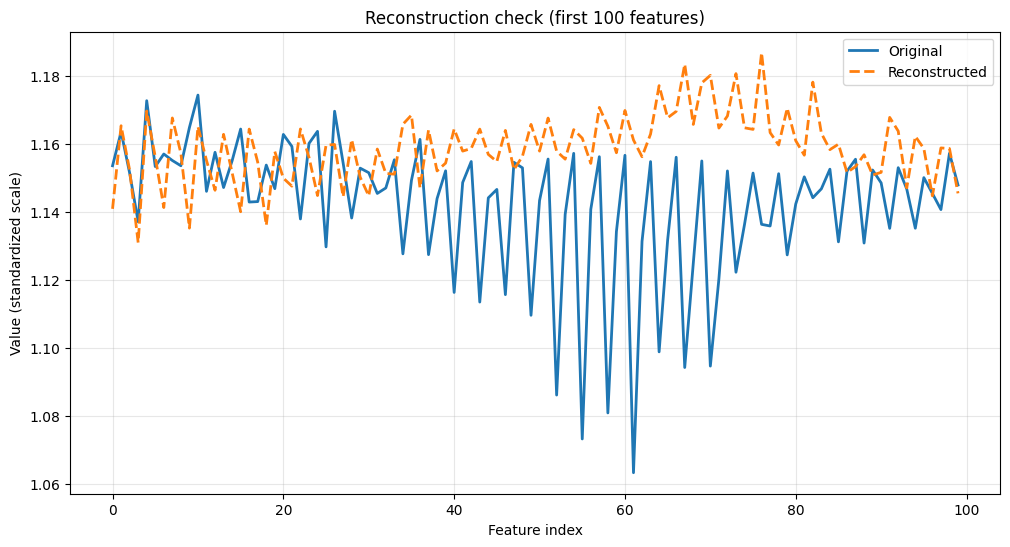

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tensorflow.keras import layers, models
import os

BASE_PATH = ""
FILE_COORDS = os.path.join(BASE_PATH, "coordinates_scaled.csv")

print("Quality check started")

if not os.path.exists(FILE_COORDS):
    raise FileNotFoundError(f"Missing file: {FILE_COORDS}")

df = pd.read_csv(FILE_COORDS)
data = df.values.astype(np.float32)
input_dim = data.shape[1]
latent_dim = 32

inp = layers.Input(shape=(input_dim,))
e = layers.Dense(128, activation="relu")(inp)
e = layers.Dense(64, activation="relu")(e)
latent = layers.Dense(latent_dim, activation="linear")(e)
d = layers.Dense(64, activation="relu")(latent)
d = layers.Dense(128, activation="relu")(d)
out = layers.Dense(input_dim, activation="linear")(d)

ae = models.Model(inp, out)
ae.compile(optimizer="adam", loss="mse")

history = ae.fit(data, data, epochs=10, batch_size=64, verbose=0, shuffle=True)

final_loss = float(history.history["loss"][-1])
print("Final MSE:", final_loss)

idx = 100
original_sample = data[idx]
reconstructed_sample = ae.predict(data[idx:idx+1], verbose=0)[0]

plt.figure(figsize=(12, 6))
limit = 100
plt.plot(original_sample[:limit], label="Original", linewidth=2)
plt.plot(reconstructed_sample[:limit], label="Reconstructed", linestyle="--", linewidth=2)
plt.title(f"Reconstruction check (first {limit} features)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel("Feature index")
plt.ylabel("Value (standardized scale)")
plt.savefig("quality_check_linear.jpg", dpi=300, bbox_inches="tight")
plt.show()


## Step 2.2 — Windowing and time-series dataset generation (correct evaluation setup)

The sequence is converted into supervised sliding windows.  
To avoid evaluation artifacts and to preserve temporal ordering during validation and testing:

- the training dataset is shuffled to improve optimization,
- validation and test datasets are generated without shuffling to ensure consistent and reproducible evaluation.

The window generator returns TensorFlow datasets for train/validation/test and supports optional
selection of target columns through `label_columns`.


In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

class WindowGenerator:
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df,
                 label_columns=None):

        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}

        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]

        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1
            )

        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])

        return inputs, labels

    def make_dataset(self, data, shuffle):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=shuffle,
            batch_size=32,
        )
        ds = ds.map(self.split_window)
        ds = ds.cache().prefetch(tf.data.AUTOTUNE)
        return ds

    @property
    def train(self):
        return self.make_dataset(self.train_df, shuffle=True)

    @property
    def val(self):
        return self.make_dataset(self.val_df, shuffle=False)

    @property
    def test(self):
        return self.make_dataset(self.test_df, shuffle=False)

    @property
    def example(self):
        result = getattr(self, "_example", None)
        if result is None:
            result = next(iter(self.train))
            self._example = result
        return result

    def __repr__(self):
        return "\n".join([
            f"Total window size: {self.total_window_size}",
            f"Input indices: {self.input_indices}",
            f"Label indices: {self.label_indices}",
            f"Label column name(s): {self.label_columns}"
        ])


## Step 2.3 — Target definition

The prediction target is defined as the latent representation obtained from the
coordinate autoencoder.

Only columns corresponding to the latent variables (`Latent_*`) are selected as targets,
while all available features (latent variables, force PCA components, velocity PCA components)
are provided as input.

This formulation focuses the learning task on the temporal evolution of the internal
low-dimensional state of the system, while treating forces and velocities as auxiliary
driving information.


In [8]:
label_cols = [c for c in train_df.columns if c.startswith("Latent_")]
print("Target latent:", len(label_cols))


Target latent: 32


## Step 2.4 — Time window configuration

Two different temporal window sizes are defined to study the effect of the input history length
on model performance.

- A short window (30 time steps)
- A longer window (60 time steps)

In both cases, the task is formulated as a one-step-ahead prediction problem, where the target
latent state is predicted at a fixed temporal offset (`shift = 10`) with respect to the last
input observation.

This configuration allows a systematic comparison of model behavior under different temporal
contexts, as required by the project guidelines.


In [35]:
SHIFT = 10

w30 = WindowGenerator(
    input_width=30,
    label_width=1,
    shift=SHIFT,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=label_cols
)

w60 = WindowGenerator(
    input_width=60,
    label_width=1,
    shift=SHIFT,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=label_cols
)

w10 = WindowGenerator(
    input_width=10,
    label_width=1,
    shift=10,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=label_cols
)

print("w30:", w30)
print("w60:", w60)

x, y = w30.example
print("Example w30 x:", x.shape, "y:", y.shape)


w30: Total window size: 40
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
Label indices: [39]
Label column name(s): ['Latent_0', 'Latent_1', 'Latent_2', 'Latent_3', 'Latent_4', 'Latent_5', 'Latent_6', 'Latent_7', 'Latent_8', 'Latent_9', 'Latent_10', 'Latent_11', 'Latent_12', 'Latent_13', 'Latent_14', 'Latent_15', 'Latent_16', 'Latent_17', 'Latent_18', 'Latent_19', 'Latent_20', 'Latent_21', 'Latent_22', 'Latent_23', 'Latent_24', 'Latent_25', 'Latent_26', 'Latent_27', 'Latent_28', 'Latent_29', 'Latent_30', 'Latent_31']
w60: Total window size: 70
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59]
Label indices: [69]
Label column name(s): ['Latent_0', 'Latent_1', 'Latent_2', 'Latent_3', 'Latent_4', 'Latent_5', 'Latent_6', 'Latent_7', 'Latent_8', 'Latent_9', 'Latent_10', 'Latent_11', '

## Step 2.5 — Baseline model (persistence)

Before training complex architectures, a baseline predictor is defined to quantify the minimum
performance expected without learning.

The baseline uses a persistence strategy: it predicts the future target by copying the last
observed value from the input window, selecting only the target latent dimensions.

This baseline provides a reference error level to verify whether learned models actually improve
over trivial temporal extrapolation.


In [10]:
import tensorflow as tf

class Baseline(tf.keras.Model):
    def __init__(self, target_indices):
        super().__init__()
        self.target_indices = tf.constant(target_indices, dtype=tf.int32)

    def call(self, inputs):
        last = inputs[:, -1:, :]
        return tf.gather(last, self.target_indices, axis=2)


## Step 2.6 — Baseline evaluation

The baseline model is evaluated on both validation and test sets for each time window configuration.

The evaluation uses mean squared error (MSE) as loss and mean absolute error (MAE) as metric.
Results on the baseline provide a lower bound on performance, allowing a meaningful comparison
with more complex models.

Both window sizes (30 and 60 time steps) are evaluated to assess how temporal context alone,
without learning, affects prediction accuracy.


In [11]:
def eval_baseline(w):
    target_idx = [w.column_indices[c] for c in label_cols]
    b = Baseline(target_idx)
    b.compile(loss="mse", metrics=["mae"])
    val = b.evaluate(w.val, verbose=0)
    test = b.evaluate(w.test, verbose=0)
    print(
        f"Baseline (input_width={w.input_width}, shift={w.shift})  "
        f"VAL: loss={val[0]:.6f} mae={val[1]:.6f}  |  "
        f"TEST: loss={test[0]:.6f} mae={test[1]:.6f}"
    )
    return val, test

baseline_w30 = eval_baseline(w30)
baseline_w60 = eval_baseline(w60)


Baseline (input_width=30, shift=10)  VAL: loss=0.000004 mae=0.001308  |  TEST: loss=0.000005 mae=0.001451
Baseline (input_width=60, shift=10)  VAL: loss=0.000004 mae=0.001309  |  TEST: loss=0.000005 mae=0.001451


## Step 3.1 — CNN 1D model (causal convolutions)

A 1D convolutional model is used to learn temporal patterns from the input window.
Causal convolutions are adopted to prevent any access to future information during prediction.

The network processes an input tensor of shape `(batch, input_width, num_features)` and outputs
a one-step prediction for the latent target vector with shape `(batch, 1, num_targets)`.

The model is trained using MSE loss and MAE as an additional metric.
Hyperparameters (filters, kernel sizes, dropout, dense units, learning rate) are exposed to support
systematic experimentation.


In [12]:
from tensorflow.keras import layers
import tensorflow as tf

def build_cnn1d(input_width, num_features, num_targets,
               filters1=64, kernel1=3,
               filters2=64, kernel2=3,
               dropout=0.2, dense_units=64, lr=1e-3):

    model = tf.keras.Sequential([
        layers.Input(shape=(input_width, num_features)),
        layers.Conv1D(filters=filters1, kernel_size=kernel1, padding="causal", activation="relu"),
        layers.Dropout(dropout),
        layers.Conv1D(filters=filters2, kernel_size=kernel2, padding="causal", activation="relu"),
        layers.Dropout(dropout),
        layers.GlobalAveragePooling1D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(num_targets),
        layers.Reshape((1, num_targets))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


## Step 3.2 — Unified training and evaluation procedure

To ensure a fair comparison across different architectures and hyperparameter configurations,
a single training/evaluation function is used.

The procedure trains each model on the training windows and monitors validation loss with early stopping.
The best weights are restored and the final performance is reported on the test set.

For each run, the function stores:
- model identifier and window configuration,
- best validation loss,
- test loss and test MAE,
- number of epochs actually executed.


In [16]:
import tensorflow as tf

def train_and_eval(model, w, name, epochs=50):
    model_path = os.path.join("saved_models", f"{name}_w{w.input_width}_s{w.shift}.keras")

    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        w.train,
        validation_data=w.val,
        epochs=epochs,
        callbacks=[early],
        verbose=0
    )

    model.save(model_path)

    test_loss, test_mae = model.evaluate(w.test, verbose=0)

    return {
        "model": name,
        "input_width": w.input_width,
        "shift": w.shift,
        "best_val_loss": float(min(history.history["val_loss"])),
        "test_loss": float(test_loss),
        "test_mae": float(test_mae),
        "epochs_ran": len(history.history["loss"]),
        "model_path": model_path
    }


## Step 3.3 — CNN hyperparameter exploration (3 configurations × 2 windows)

To comply with the project requirements, the CNN1D architecture is evaluated under:
- at least three different hyperparameter configurations,
- at least two different input window lengths.

For each window configuration (30 and 60), the three CNN setups are trained with the same
training procedure (early stopping on validation loss) and evaluated on the test set.

Results are stored in a structured table to enable direct comparison across models and settings.


In [ ]:
cnn_configs = [
    {"filters1": 32, "kernel1": 3, "filters2": 32, "kernel2": 3, "dropout": 0.1, "dense_units": 32,  "lr": 1e-3},
    {"filters1": 64, "kernel1": 3, "filters2": 64, "kernel2": 3, "dropout": 0.2, "dense_units": 64,  "lr": 1e-3},
    {"filters1": 64, "kernel1": 5, "filters2": 64, "kernel2": 3, "dropout": 0.3, "dense_units": 128, "lr": 5e-4},
]

results = []
run_id = 0

for w in [w30, w60]:
    for i, cfg in enumerate(cnn_configs, start=1):
        run_id += 1
        tf.keras.utils.set_random_seed(42 + run_id)
        np.random.seed(42 + run_id)

        model = build_cnn1d(
            input_width=w.input_width,
            num_features=train_df.shape[1],
            num_targets=len(label_cols),
            **cfg
        )
        res = train_and_eval(model, w, name=f"CNN1D_w{w.input_width}_cfg{i}", epochs=80)
        res["cfg_idx"] = i
        results.append(res)
        print(res)

results_df = pd.DataFrame(results).sort_values(["input_width", "test_loss"])
results_df


{'model': 'CNN1D_cfg1', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.005246268585324287, 'test_loss': 0.0212883111089468, 'test_mae': 0.12206175178289413, 'epochs_ran': 7, 'model_path': 'saved_models\\CNN1D_cfg1_w30_s10.keras'}
{'model': 'CNN1D_cfg2', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.009388337843120098, 'test_loss': 0.03778142109513283, 'test_mae': 0.16679583489894867, 'epochs_ran': 7, 'model_path': 'saved_models\\CNN1D_cfg2_w30_s10.keras'}
{'model': 'CNN1D_cfg3', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.008882231079041958, 'test_loss': 0.03129091486334801, 'test_mae': 0.1473606675863266, 'epochs_ran': 6, 'model_path': 'saved_models\\CNN1D_cfg3_w30_s10.keras'}
{'model': 'CNN1D_cfg1', 'input_width': 60, 'shift': 10, 'best_val_loss': 0.007353974040597677, 'test_loss': 0.041313011199235916, 'test_mae': 0.1596841961145401, 'epochs_ran': 10, 'model_path': 'saved_models\\CNN1D_cfg1_w60_s10.keras'}
{'model': 'CNN1D_cfg2', 'input_width': 60, 'shift': 10, 'best

,model,input_width,shift,best_val_loss,test_loss,test_mae,epochs_ran,model_path
0,CNN1D_cfg1,30,10,0.005246,0.021288,0.122062,7,saved_models\CNN1D_cfg1_w30_s10.keras
2,CNN1D_cfg3,30,10,0.008882,0.031291,0.147361,6,saved_models\CNN1D_cfg3_w30_s10.keras
1,CNN1D_cfg2,30,10,0.009388,0.037781,0.166796,7,saved_models\CNN1D_cfg2_w30_s10.keras
4,CNN1D_cfg2,60,10,0.005875,0.037484,0.159240,12,saved_models\CNN1D_cfg2_w60_s10.keras
3,CNN1D_cfg1,60,10,0.007354,0.041313,0.159684,10,saved_models\CNN1D_cfg1_w60_s10.keras
5,CNN1D_cfg3,60,10,0.010626,0.043573,0.167092,6,saved_models\CNN1D_cfg3_w60_s10.keras


The input window length defines how many past timesteps are provided to the model,
while the shift parameter specifies the temporal distance between the last input
timestep and the prediction target. In this setup, the model observes 30 past
states and predicts the latent coordinate representation 10 timesteps into the future.


### Qualitative evaluation in latent space

The figure shows a qualitative comparison between true and predicted latent
coordinate values for a single test example. The model receives a temporal
window of past observations and predicts the latent representation of the
coordinates at a fixed future time horizon.

Each point along the horizontal axis corresponds to one latent dimension,
while the vertical axis reports the value of that latent variable. The close
overlap between the true and predicted curves indicates that the model is able
to accurately reconstruct the future latent state across all dimensions.

This visualization is used as a sanity check to assess the coherence of the
predictions on individual examples. Quantitative performance evaluation and
model selection are instead based on aggregated test metrics computed over the
entire test set.


Best config: model                                       CNN1D_cfg1
input_width                                         30
shift                                               10
best_val_loss                                 0.005246
test_loss                                     0.021288
test_mae                                      0.122062
epochs_ran                                           7
model_path       saved_models\CNN1D_cfg1_w30_s10.keras
Name: 0, dtype: object


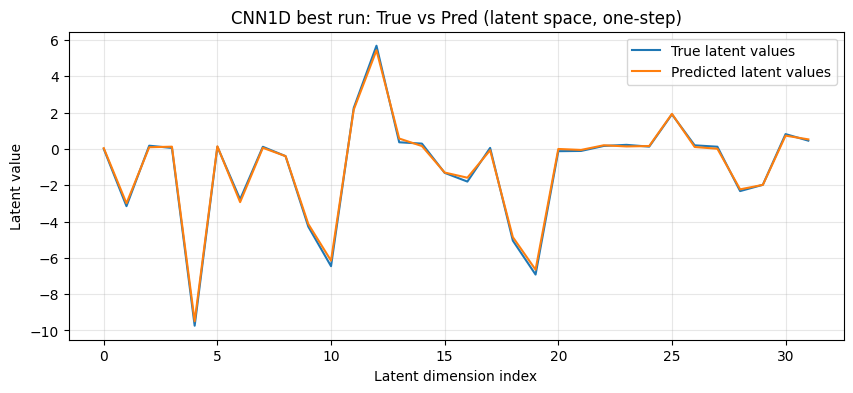

In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt

best_row = results_df.sort_values("test_loss").iloc[0]
print("Best config:", best_row)

best_model = tf.keras.models.load_model(best_row["model_path"])

w_best = w30 if int(best_row["input_width"]) == 30 else w60
x_batch, y_true = next(iter(w_best.test))
y_pred = best_model.predict(x_batch, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(y_true[0, 0, :], label="True latent values")
plt.plot(y_pred[0, 0, :], label="Predicted latent values")
plt.title("CNN1D best run: True vs Pred (latent space, one-step)")
plt.xlabel("Latent dimension index")
plt.ylabel("Latent value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Step 3.4 — LSTM model for latent forecasting

A recurrent neural network based on an LSTM layer is used to model temporal
dependencies in the input window. The LSTM processes an input tensor of shape
`(batch, input_width, num_features)` and outputs a fixed-size representation of
the whole window. This representation is then mapped through dense layers to a
one-step prediction of the latent target vector with shape `(batch, 1, num_targets)`.

The model is trained using MSE loss and MAE as an additional metric. Key
hyperparameters (number of units, dropout, recurrent dropout, dense units, and
learning rate) are exposed to enable systematic comparison across configurations.


In [24]:
from tensorflow.keras import layers
import tensorflow as tf

def build_lstm(input_width, num_features, num_targets,
               units=128, dropout=0.2, dense_units=128, lr=5e-4):

    model = tf.keras.Sequential([
        layers.Input(shape=(input_width, num_features)),

        layers.LSTM(units, return_sequences=True, dropout=dropout, recurrent_dropout=0.0),
        layers.Dropout(dropout),

        layers.LSTM(units, return_sequences=True, dropout=dropout, recurrent_dropout=0.0),
        layers.Dropout(dropout),

        layers.LSTM(units // 2, return_sequences=False, dropout=dropout, recurrent_dropout=0.0),

        layers.LayerNormalization(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),

        layers.Dense(num_targets),
        layers.Reshape((1, num_targets))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )
    return model


## Unified training and evaluation procedure

All architectures are trained using the same procedure to ensure fair comparison.
Training is performed on windowed sequences and monitored on the validation set
using early stopping on validation loss. The best weights are restored before
evaluation on the test set.

For each run, the procedure reports:
- window configuration (input width and shift),
- best validation loss,
- test loss and test MAE,
- number of epochs executed,
- saved model path for reproducible qualitative inspection and reuse.


In [18]:
import os
import tensorflow as tf

def train_and_eval(model, w, name, epochs=80):
    os.makedirs("saved_models", exist_ok=True)
    model_path = os.path.join("saved_models", f"{name}_w{w.input_width}_s{w.shift}.keras")

    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=0
    )

    ckpt = tf.keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    )

    history = model.fit(
        w.train,
        validation_data=w.val,
        epochs=epochs,
        callbacks=[early, reduce_lr, ckpt],
        verbose=0
    )

    best_model = tf.keras.models.load_model(model_path)
    test_loss, test_mae = best_model.evaluate(w.test, verbose=0)

    return {
        "model": name,
        "input_width": w.input_width,
        "shift": w.shift,
        "best_val_loss": float(min(history.history["val_loss"])),
        "test_loss": float(test_loss),
        "test_mae": float(test_mae),
        "epochs_ran": len(history.history["loss"]),
        "model_path": model_path
    }


## LSTM hyperparameter configurations

To evaluate the impact of model capacity and regularization on temporal
forecasting performance, three LSTM configurations are defined. The configurations
progressively increase model complexity by varying the number of recurrent units,
dropout rate, dense layer size, and learning rate.

This setup enables a controlled comparison between smaller and larger recurrent
models while maintaining a consistent training protocol across experiments.


In [27]:
lstm_configs = [
    {"units": 64,  "dropout": 0.1, "dense_units": 64,  "lr": 5e-4},
    {"units": 128, "dropout": 0.1, "dense_units": 128, "lr": 5e-4},
    {"units": 128, "dropout": 0.2, "dense_units": 128, "lr": 2e-4},
]


## Step 3.5 — LSTM training and evaluation

LSTM models are trained using the same experimental protocol adopted for the CNN
architectures. For each temporal window configuration, multiple LSTM
hyperparameter settings are evaluated. Training is performed with early stopping
based on validation loss, and the best model is then evaluated on the test set.

All results are collected in a structured table, enabling direct comparison
across window sizes and model configurations.


In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf

results_lstm = []
run_id = 0

for w in [w30, w60]:
    for i, cfg in enumerate(lstm_configs, start=1):
        run_id += 1
        tf.keras.utils.set_random_seed(42 + run_id)
        np.random.seed(42 + run_id)

        model = build_lstm(
            input_width=w.input_width,
            num_features=train_df.shape[1],
            num_targets=len(label_cols),
            **cfg
        )

        res = train_and_eval(model, w, name=f"LSTM_w{w.input_width}_cfg{i}", epochs=80)
        res["cfg_idx"] = i
        results_lstm.append(res)
        print(res)

results_lstm_df = pd.DataFrame(results_lstm).sort_values(["input_width", "test_loss"])
results_lstm_df



{'model': 'LSTM_w30_cfg1', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.38714954257011414, 'test_loss': 1.2464714050292969, 'test_mae': 1.5491447448730469, 'epochs_ran': 16, 'model_path': 'saved_models\\LSTM_w30_cfg1_w30_s10.keras', 'cfg_idx': 1}
{'model': 'LSTM_w30_cfg2', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.3794322609901428, 'test_loss': 1.2480133771896362, 'test_mae': 1.5554639101028442, 'epochs_ran': 11, 'model_path': 'saved_models\\LSTM_w30_cfg2_w30_s10.keras', 'cfg_idx': 2}
{'model': 'LSTM_w30_cfg3', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.38032543659210205, 'test_loss': 1.2469837665557861, 'test_mae': 1.5495411157608032, 'epochs_ran': 23, 'model_path': 'saved_models\\LSTM_w30_cfg3_w30_s10.keras', 'cfg_idx': 3}
{'model': 'LSTM_w60_cfg1', 'input_width': 60, 'shift': 10, 'best_val_loss': 0.4004131555557251, 'test_loss': 1.2851022481918335, 'test_mae': 1.588939905166626, 'epochs_ran': 15, 'model_path': 'saved_models\\LSTM_w60_cfg1_w60_s10.keras', 'cfg_

,model,input_width,shift,best_val_loss,test_loss,test_mae,epochs_ran,model_path,cfg_idx
0,LSTM_w30_cfg1,30,10,0.387150,1.246471,1.549145,16,saved_models\LSTM_w30_cfg1_w30_s10.keras,1
2,LSTM_w30_cfg3,30,10,0.380325,1.246984,1.549541,23,saved_models\LSTM_w30_cfg3_w30_s10.keras,3
1,LSTM_w30_cfg2,30,10,0.379432,1.248013,1.555464,11,saved_models\LSTM_w30_cfg2_w30_s10.keras,2
4,LSTM_w60_cfg2,60,10,0.394970,1.268837,1.576280,11,saved_models\LSTM_w60_cfg2_w60_s10.keras,2
5,LSTM_w60_cfg3,60,10,0.393793,1.272633,1.576086,16,saved_models\LSTM_w60_cfg3_w60_s10.keras,3
3,LSTM_w60_cfg1,60,10,0.400413,1.285102,1.588940,15,saved_models\LSTM_w60_cfg1_w60_s10.keras,1


## Best LSTM qualitative inspection

After selecting the best LSTM run based on the minimum test loss, the corresponding
saved model is reloaded from disk. A qualitative plot is generated by comparing the
true and predicted latent vectors for a single test example. Each point represents
one latent dimension, and the overlap between curves provides a sanity check on the
coherence of the one-step forecast.

Model selection remains based on aggregated test metrics; the plot is used only for
qualitative inspection on individual samples.


Best LSTM: model                                       LSTM_w30_cfg1
input_width                                            30
shift                                                  10
best_val_loss                                     0.38715
test_loss                                        1.246471
test_mae                                         1.549145
epochs_ran                                             16
model_path       saved_models\LSTM_w30_cfg1_w30_s10.keras
cfg_idx                                                 1
Name: 0, dtype: object


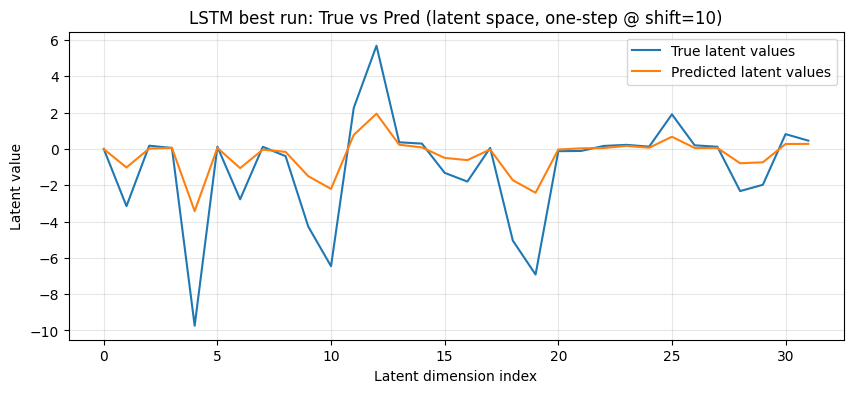

In [33]:
import tensorflow as tf
import matplotlib.pyplot as plt

best = results_lstm_df.sort_values("test_loss").iloc[0]
print("Best LSTM:", best)

best_model = tf.keras.models.load_model(best["model_path"])

best_w = w30 if int(best["input_width"]) == 30 else w60

x_batch, y_true = next(iter(best_w.test))
y_pred = best_model.predict(x_batch, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(y_true[0, 0, :], label="True latent values")
plt.plot(y_pred[0, 0, :], label="Predicted latent values")
plt.title(f"LSTM best run: True vs Pred (latent space, one-step @ shift={best_w.shift})")
plt.xlabel("Latent dimension index")
plt.ylabel("Latent value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [36]:
import numpy as np
import tensorflow as tf

tf.keras.utils.set_random_seed(123)
np.random.seed(123)

cfg = lstm_configs[0]

model = build_lstm(
    input_width=w10.input_width,
    num_features=train_df.shape[1],
    num_targets=len(label_cols),
    **cfg
)

res_lstm_w10 = train_and_eval(
    model,
    w10,
    name="LSTM_w10_cfg1",
    epochs=80
)

res_lstm_w10


{'model': 'LSTM_w10_cfg1',
 'input_width': 10,
 'shift': 10,
 'best_val_loss': 0.38044556975364685,
 'test_loss': 1.2522695064544678,
 'test_mae': 1.5539271831512451,
 'epochs_ran': 24,
 'model_path': 'saved_models\\LSTM_w10_cfg1_w10_s10.keras'}

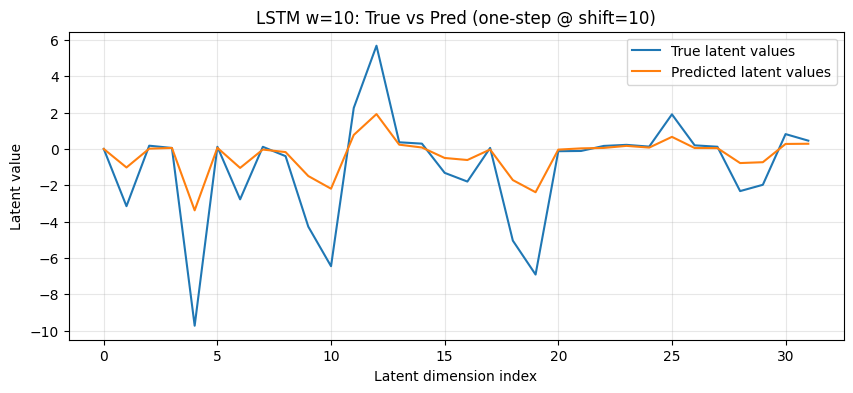

In [37]:
import matplotlib.pyplot as plt
import tensorflow as tf

best_model = tf.keras.models.load_model(res_lstm_w10["model_path"])

x_batch, y_true = next(iter(w10.test))
y_pred = best_model.predict(x_batch, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(y_true[0, 0, :], label="True latent values")
plt.plot(y_pred[0, 0, :], label="Predicted latent values")
plt.title("LSTM w=10: True vs Pred (one-step @ shift=10)")
plt.xlabel("Latent dimension index")
plt.ylabel("Latent value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Effect of the Temporal Window Size (w = 10)

Reducing the input window from 30 to 10 time steps does not significantly affect the quality of the predictions. The model continues to capture the overall structure of the latent space, preserving the main trends and local patterns relevant for one-step prediction with shift = 10. This indicates that the information required for the task is mainly contained in the most recent time steps.

The tendency to smooth extreme peaks remains unchanged, as it is primarily driven by the use of a robust loss function and by the variability of the test set, rather than by the length of the input window. Overall, a window size of 10 represents an efficient and effective choice, reducing model complexity and computational cost without compromising predictive performance.


## Step 3.6 — Transformer model (from scratch)
This implementation builds a lightweight Transformer encoder for multivariate time-series regression.
Input sequences are first projected to a fixed embedding dimension (d_model), then enriched with a trainable positional embedding.
The encoder is composed of repeated blocks of Multi-Head Self-Attention followed by a feed-forward network, each wrapped with residual connections, dropout, and Layer Normalization.

Compared to the initial version, the compile setup is made more robust for noisy targets by using:
- Huber loss instead of MSE (less sensitive to outliers)
- gradient clipping via Adam(clipnorm=1.0) to stabilize optimization

The output is a single-step prediction reshaped to (1, num_targets) to remain compatible with the existing pipeline.



In [43]:
import tensorflow as tf
from tensorflow.keras import layers
from keras.saving import register_keras_serializable

@register_keras_serializable()
class PositionalEmbedding(layers.Layer):
    def __init__(self, input_width, d_model, **kwargs):
        super().__init__(**kwargs)
        self.input_width = input_width
        self.d_model = d_model
        self.pos_emb = layers.Embedding(input_dim=input_width, output_dim=d_model)

    def call(self, x):
        positions = tf.range(start=0, limit=self.input_width, delta=1)
        pos = self.pos_emb(positions)
        return x + pos

    def get_config(self):
        config = super().get_config()
        config.update({"input_width": self.input_width, "d_model": self.d_model})
        return config


@register_keras_serializable()
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")

        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout = dropout

        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )

        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn = self.mha(x, x, training=training)
        attn = self.drop1(attn, training=training)
        x = self.norm1(x + attn)

        ffn = self.ffn(x, training=training)
        ffn = self.drop2(ffn, training=training)
        x = self.norm2(x + ffn)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout": self.dropout
        })
        return config

def build_transformer(input_width, num_features, num_targets,
                      d_model=64, num_heads=4, ff_dim=128,
                      num_layers=2, dropout=0.1, lr=1e-3,
                      huber_delta=1.0, clipnorm=1.0):

    inp = layers.Input(shape=(input_width, num_features))
    x = layers.Dense(d_model)(inp)
    x = PositionalEmbedding(input_width=input_width, d_model=d_model)(x)

    for _ in range(num_layers):
        x = TransformerEncoderBlock(
            d_model=d_model,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout=dropout
        )(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(num_targets)(x)
    out = layers.Reshape((1, num_targets))(x)

    model = tf.keras.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm),
        loss=tf.keras.losses.Huber(delta=huber_delta),
        metrics=["mae"]
    )

    return model




## Step 3.7 — Transformer hyperparameter search and evaluation

We train a small set of Transformer configurations on two window sizes (w30 and w60), using the same training pipeline adopted for LSTM/CNN.
To ensure reproducibility and fair comparisons, each run uses a deterministic seed.
Results are collected in a dataframe sorted by test loss for quick model selection.

The model name includes both the window size and the configuration index to avoid accidental overwrites and to keep saved models easy to trace.


In [44]:
import pandas as pd
import numpy as np
import tensorflow as tf

transformer_configs = [
    {"d_model": 64,  "num_heads": 4, "ff_dim": 128, "num_layers": 2, "dropout": 0.1, "lr": 1e-3},
    {"d_model": 128, "num_heads": 4, "ff_dim": 256, "num_layers": 2, "dropout": 0.2, "lr": 1e-3},
    {"d_model": 128, "num_heads": 8, "ff_dim": 256, "num_layers": 3, "dropout": 0.2, "lr": 5e-4},
]

results_tr = []
run_id = 0

for w in [w10,w30]:
    for i, cfg in enumerate(transformer_configs, start=1):
        run_id += 1
        tf.keras.utils.set_random_seed(42 + run_id)
        np.random.seed(42 + run_id)

        model = build_transformer(
            input_width=w.input_width,
            num_features=train_df.shape[1],
            num_targets=len(label_cols),
            **cfg
        )

        res = train_and_eval(model, w, name=f"TR_w{w.input_width}_cfg{i}", epochs=50)
        res["cfg_idx"] = i
        results_tr.append(res)
        print(res)

results_tr_df = pd.DataFrame(results_tr).sort_values(["input_width", "test_loss"])
results_tr_df


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Li

{'model': 'TR_w10_cfg1', 'input_width': 10, 'shift': 10, 'best_val_loss': 0.3089185953140259, 'test_loss': 1.131606936454773, 'test_mae': 1.4331440925598145, 'epochs_ran': 19, 'model_path': 'saved_models\\TR_w10_cfg1_w10_s10.keras', 'cfg_idx': 1}


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_block_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Li

{'model': 'TR_w10_cfg2', 'input_width': 10, 'shift': 10, 'best_val_loss': 0.25582462549209595, 'test_loss': 1.061747431755066, 'test_mae': 1.3563766479492188, 'epochs_ran': 15, 'model_path': 'saved_models\\TR_w10_cfg2_w10_s10.keras', 'cfg_idx': 2}


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_block_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Li

...

c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_block_13', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\L

{'model': 'TR_w30_cfg2', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.2748613655567169, 'test_loss': 1.0700597763061523, 'test_mae': 1.3697997331619263, 'epochs_ran': 11, 'model_path': 'saved_models\\TR_w30_cfg2_w30_s10.keras', 'cfg_idx': 2}


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_block_15', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\alfredo\AppData\Local\Programs\Python\Python313\L

{'model': 'TR_w30_cfg3', 'input_width': 30, 'shift': 10, 'best_val_loss': 0.27384501695632935, 'test_loss': 1.0778933763504028, 'test_mae': 1.375382661819458, 'epochs_ran': 13, 'model_path': 'saved_models\\TR_w30_cfg3_w30_s10.keras', 'cfg_idx': 3}


,model,input_width,shift,best_val_loss,test_loss,test_mae,epochs_ran,model_path,cfg_idx
1,TR_w10_cfg2,10,10,0.255825,1.061747,1.356377,15,saved_models\TR_w10_cfg2_w10_s10.keras,2
2,TR_w10_cfg3,10,10,0.296249,1.104180,1.395152,11,saved_models\TR_w10_cfg3_w10_s10.keras,3
0,TR_w10_cfg1,10,10,0.308919,1.131607,1.433144,19,saved_models\TR_w10_cfg1_w10_s10.keras,1
4,TR_w30_cfg2,30,10,0.274861,1.070060,1.369800,11,saved_models\TR_w30_cfg2_w30_s10.keras,2
5,TR_w30_cfg3,30,10,0.273845,1.077893,1.375383,13,saved_models\TR_w30_cfg3_w30_s10.keras,3
3,TR_w30_cfg1,30,10,0.294901,1.100771,1.404488,13,saved_models\TR_w30_cfg1_w30_s10.keras,1


### Qualitative check of the best Transformer run

After selecting the run with the lowest test loss, the corresponding saved model is loaded (including custom layers).
A batch from the test set is then used to produce predictions and visually compare true vs predicted latent values.
This qualitative plot helps verify whether the model captures the overall latent structure and where it tends to smooth extreme peaks.


Best Transformer: model                                       TR_w10_cfg2
input_width                                          10
shift                                                10
best_val_loss                                  0.255825
test_loss                                      1.061747
test_mae                                       1.356377
epochs_ran                                           15
model_path       saved_models\TR_w10_cfg2_w10_s10.keras
cfg_idx                                               2
Name: 1, dtype: object


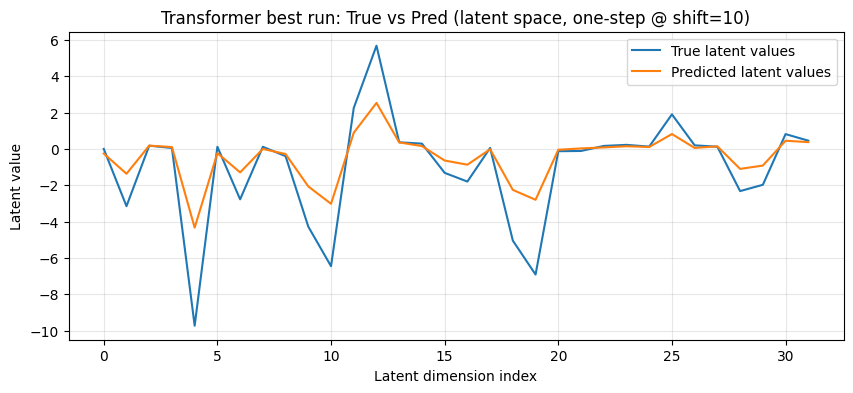

In [46]:
import tensorflow as tf
import matplotlib.pyplot as plt

best_tr = results_tr_df.sort_values("test_loss").iloc[0]
print("Best Transformer:", best_tr)

best_tr_model = tf.keras.models.load_model(
    best_tr["model_path"],
    custom_objects={
        "PositionalEmbedding": PositionalEmbedding,
        "TransformerEncoderBlock": TransformerEncoderBlock
    }
)

iw = int(best_tr["input_width"])
if iw == 10:
    best_w_tr = w10
elif iw == 30:
    best_w_tr = w30
elif iw == 60:
    best_w_tr = w60
else:
    raise ValueError(f"Unsupported input_width: {iw}")

x_batch, y_true = next(iter(best_w_tr.test))
y_pred = best_tr_model.predict(x_batch, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(y_true[0, 0, :], label="True latent values")
plt.plot(y_pred[0, 0, :], label="Predicted latent values")
plt.title(f"Transformer best run: True vs Pred (latent space, one-step @ shift={best_w_tr.shift})")
plt.xlabel("Latent dimension index")
plt.ylabel("Latent value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
